# D-Wave post-run analysis (no remote calls)

Run this only after the hybrid campaign. It reads saved results and compares D-Wave with the existing 30-s CPLEX and long-SA baselines. It does **not** submit anything to D-Wave.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path('dwave_hybrid_results')
BASE = Path('baseline_results')
FIG = OUT/'figures'; FIG.mkdir(parents=True, exist_ok=True)

dw = pd.read_csv(OUT/'dwave_hybrid_summary.csv')
base = pd.read_csv(BASE/'revised_solver_benchmark.csv')
print('D-Wave events:', len(dw))
display(dw)

D-Wave events: 20


,objective_direct,tracking_objective,once_penalty,duplicate_starts,n_jobs_scheduled,tracking_RMSE_kW,max_envelope_violation_kW,envelope_violation_kWh,max_concurrent_gpus,cluster_gpu_capacity,...,qubo_energy_recomputed,energy_abs_difference,charge_time_raw,charge_time_s,run_time_raw,run_time_s,qpu_access_time_raw,qpu_access_time_s,physical_feasible,campaign_sequence
0,0.013091,0.013091,0.0,0,10,0.549407,0.000000,0.000000,61,256,...,0.013091,2.470246e-15,29994200,29.994200,29994200,29.994200,1601916,1.601916,True,1
1,0.014417,0.014417,0.0,0,9,0.576562,0.000000,0.000000,70,256,...,0.014417,2.664535e-15,29990391,29.990391,29990391,29.990391,1653023,1.653023,True,2
2,0.010683,0.010683,0.0,0,9,0.496327,0.000000,0.000000,65,256,...,0.010683,0.000000e+00,29987324,29.987324,29987324,29.987324,1601902,1.601902,True,3
3,0.010041,0.010041,0.0,0,7,0.481171,0.000000,0.000000,52,256,...,0.010041,3.330669e-16,29988913,29.988913,29988913,29.988913,1601919,1.601919,True,4
4,0.009150,0.009150,0.0,0,8,0.459324,0.000000,0.000000,62,256,...,0.009150,2.220446e-16,29993947,29.993947,29993947,29.993947,1550304,1.550304,True,5
5,0.020567,0.020567,0.0,0,10,0.688645,0.000000,0.000000,58,256,...,0.020567,1.200429e-15,29988318,29.988318,29988318,29.988318,1601961,1.601961,True,6
6,0.015749,0.015749,0.0,0,8,0.602608,0.000000,0.000000,54,256,...,0.015749,1.776357e-15,29999055,29.999055,29999055,29.999055,1653596,1.653596,True,7
7,0.014379,0.014379,0.0,0,9,0.575801,0.000000,0.000000,64,256,...,0.014379,8.881784e-16,29992571,29.992571,29992571,29.992571,1343600,1.343600,True,8
8,0.013192,0.013192,0.0,0,9,0.551527,0.000000,0.000000,53,256,...,0.013192,9.992007e-16,29996606,29.996606,29996606,29.996606,1601920,1.601920,True,9
9,0.005225,0.005225,0.0,0,8,0.347114,0.000000,0.000000,49,256,...,0.005225,8.604228e-16,29987834,29.987834,29987834,29.987834,1653648,1.653648,True,10


In [2]:
# Strict same-BQM comparison on the three events already solved by CPLEX-QUBO.
rows=[]
for eid in sorted(set(dw.event_id).intersection(set(base.event_id))):
    d = dw[dw.event_id==eid].iloc[0]
    b = base[base.event_id==eid].set_index('method')
    row={'event_id':int(eid),'DWave':float(d.objective_direct)}
    for method in ['CPLEX-QUBO','CPLEX-constrained','SA']:
        if method in b.index:
            row[method]=float(b.loc[method,'objective_direct'])
            row[f'DWave_improvement_vs_{method}_pct']=100*(float(b.loc[method,'objective_direct'])-float(d.objective_direct))/float(b.loc[method,'objective_direct'])
            row[f'{method}_wall_time_s']=float(b.loc[method,'wall_time_s'])
    row['DWave_client_wall_time_s']=float(d.client_wall_time_s)
    rows.append(row)
cmp=pd.DataFrame(rows)
cmp.to_csv(OUT/'dwave_vs_existing_baselines.csv',index=False)
display(cmp)

,event_id,DWave,CPLEX-QUBO,DWave_improvement_vs_CPLEX-QUBO_pct,CPLEX-QUBO_wall_time_s,CPLEX-constrained,DWave_improvement_vs_CPLEX-constrained_pct,CPLEX-constrained_wall_time_s,SA,DWave_improvement_vs_SA_pct,SA_wall_time_s,DWave_client_wall_time_s
0,0,0.013091,0.238697,94.515782,30.078925,0.092008,85.772219,30.165970,0.023260,43.719165,420.363740,37.855577
1,1,0.014417,0.105449,86.328364,30.057039,0.077199,81.325468,30.099090,0.024925,42.160288,422.488879,39.276132
2,2,0.010683,0.193738,94.485675,30.087665,0.075119,85.778105,30.217004,0.016526,35.352529,416.890426,39.842047


In [3]:
# Publication-safe resource summary.
for col in ['run_time_s','charge_time_s','qpu_access_time_s','client_wall_time_s']:
    if col in dw:
        print(col, 'mean=',dw[col].mean(),'total=',dw[col].sum(),'min=',dw[col].min(),'max=',dw[col].max())
print('physical feasible:', dw.get('physical_feasible', pd.Series(dtype=bool)).value_counts(dropna=False).to_dict())

run_time_s mean= 29.991656850000005 total= 599.8331370000001 min= 29.987324 max= 29.999121
charge_time_s mean= 29.991656850000005 total= 599.8331370000001 min= 29.987324 max= 29.999121
qpu_access_time_s mean= 1.6096536999999997 total= 32.193073999999996 min= 1.3436 max= 1.653662
client_wall_time_s mean= 38.76190603999712 total= 775.2381207999424 min= 37.29774650000036 max= 42.50432229999569
physical feasible: {True: 19, False: 1}


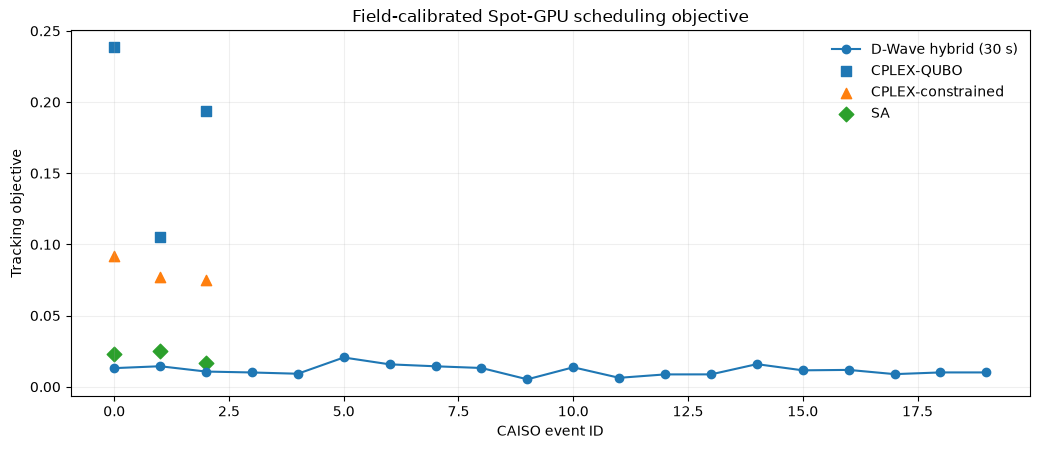

In [4]:
# Figure 1: objective over all 20 D-Wave events, with first-three classical baselines.
fig, ax = plt.subplots(figsize=(10.5,4.6))
ax.plot(dw.event_id, dw.objective_direct, marker='o', label='D-Wave hybrid (30 s)')
for method, marker in [('CPLEX-QUBO','s'),('CPLEX-constrained','^'),('SA','D')]:
    z=base[base.method==method]
    ax.scatter(z.event_id, z.objective_direct, marker=marker, s=55, label=method)
ax.set_xlabel('CAISO event ID'); ax.set_ylabel('Tracking objective')
ax.set_title('Field-calibrated Spot-GPU scheduling objective')
ax.grid(alpha=0.2); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG/'dwave_objective_all_events.pdf'); plt.show()

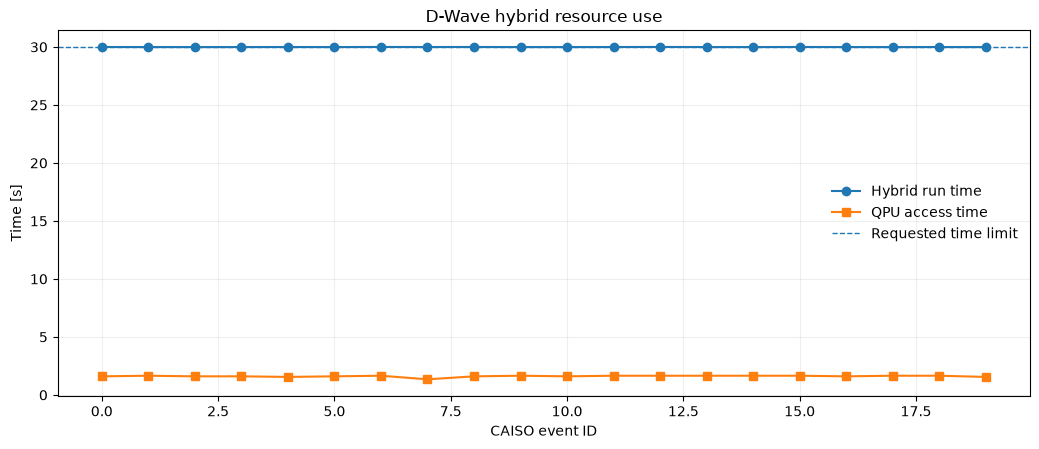

In [5]:
# Figure 2: hybrid runtime and actual QPU access.
fig, ax = plt.subplots(figsize=(10.5,4.6))
ax.plot(dw.event_id, dw.run_time_s, marker='o', label='Hybrid run time')
ax.plot(dw.event_id, dw.qpu_access_time_s, marker='s', label='QPU access time')
ax.axhline(30.0, ls='--', lw=1, label='Requested time limit')
ax.set_xlabel('CAISO event ID'); ax.set_ylabel('Time [s]')
ax.set_title('D-Wave hybrid resource use')
ax.grid(alpha=0.2); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG/'dwave_timing_all_events.pdf'); plt.show()

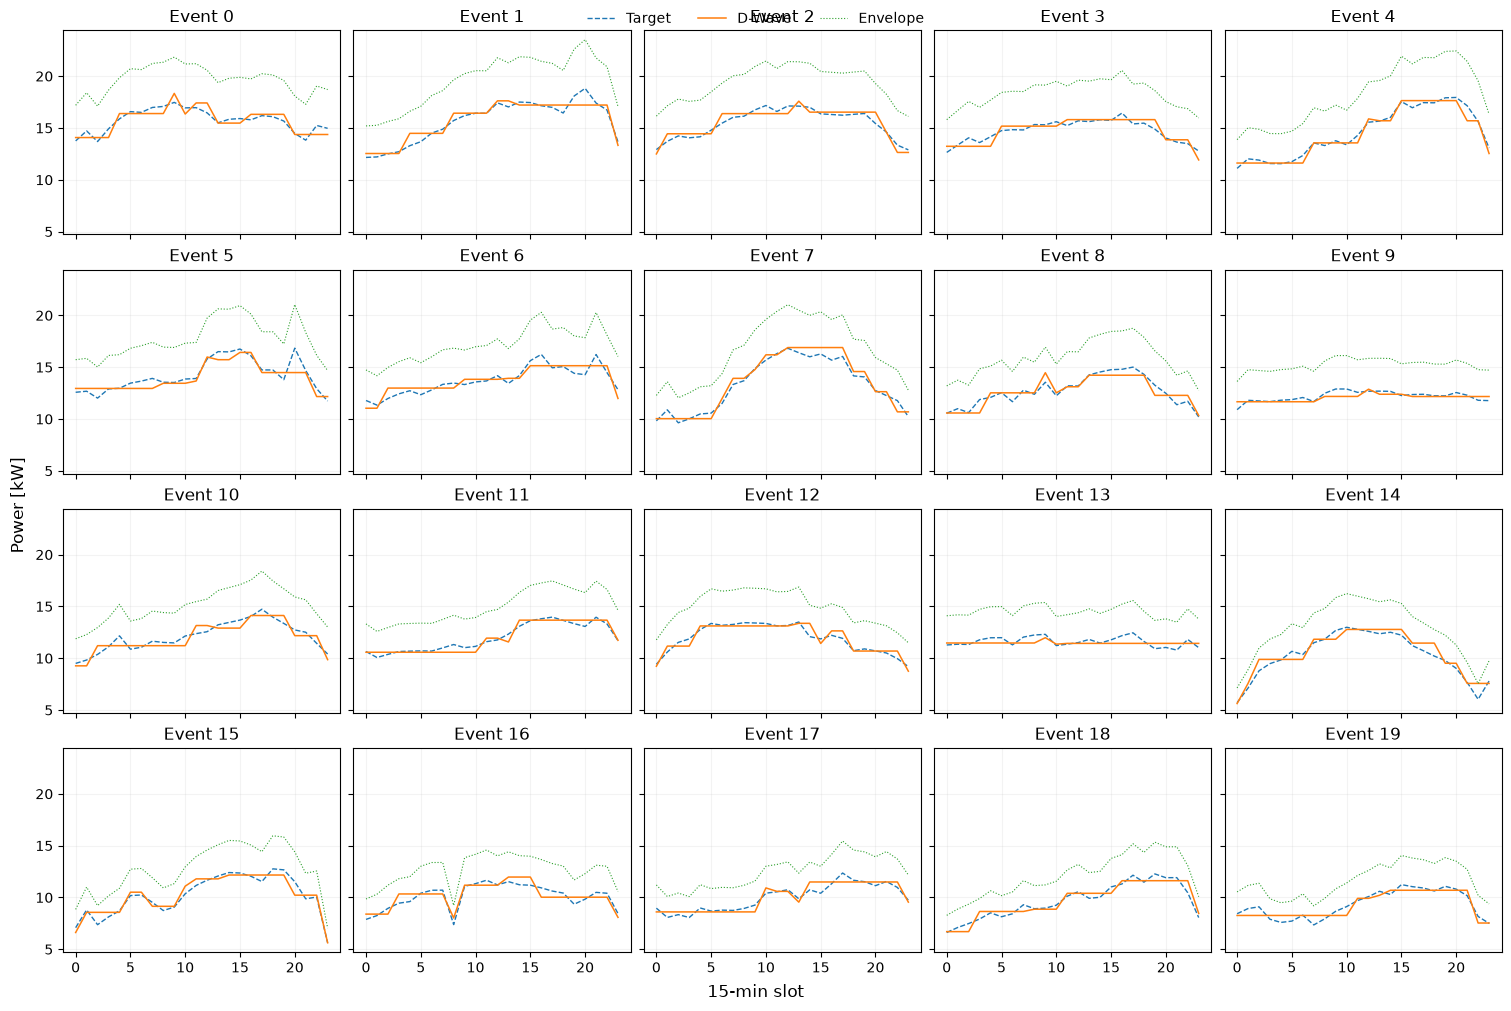

In [6]:
# Figure 3: event-level power tracking for all D-Wave runs.
profiles=pd.read_csv('prepared_ai_curtailment_dvfs/event_profiles_long.csv', parse_dates=['timestamp'])
fig, axes = plt.subplots(4,5,figsize=(15,10),sharex=True,sharey=True,constrained_layout=True)
for ax,eid in zip(axes.ravel(), range(20)):
    ep=profiles[profiles.event_id==eid].sort_values('slot')
    tr=pd.read_csv(OUT/'events'/f'event_{eid:02d}'/'trajectory.csv')
    ax.plot(ep.slot, ep.dispatch_target_kW, ls='--', lw=1, label='Target' if eid==0 else None)
    ax.plot(ep.slot, tr.dwave_gpu_load_kW, lw=1.1, label='D-Wave' if eid==0 else None)
    ax.plot(ep.slot, ep.allocated_curtailment_kW, ls=':', lw=.8, label='Envelope' if eid==0 else None)
    ax.set_title(f'Event {eid}')
    ax.grid(alpha=.15)
fig.supxlabel('15-min slot'); fig.supylabel('Power [kW]')
handles,labels=axes.ravel()[0].get_legend_handles_labels(); fig.legend(handles,labels,loc='upper center',ncol=3,frameon=False)
fig.savefig(FIG/'dwave_tracking_20_events.pdf'); plt.show()